# DEMONEXT `Guider` Class Sandbox

Sandbox for testing the new DEMONEXT `Guider` class that implements a variant on Steven Villanueva's
science guiding algorithm from the first DEMONEXT observatory that operated at Winer Observatory
from 2016 until 2021.  

Our variant uses `sep` and methods from `scipy` and `astropy` doing star finding, matching, and guider
calibrations using DEMONEXT sciences images. 

This vesion of the notebook tests the `Guider` implementation, wrapping visualizations and analysis
on top of the class methods that will go into the robotic system,

The origins of many of the different methods we are incorporating in version are derived from a set of programs
developed for the SDSS-V fiber positioner project to measure spots on fiber viewing camera images during
commissioning. Before application to the 2025 DEMONEXT reboot, we applies some of those methods to develop
more star/object finding and inter-image coordinate transformations, a few of which were the basis for what we've
developed for DEMONEXT.

## Star finding

We use `sep` v.1.2.1 (https://sep.readthedocs.io/en/stable), a Python port of Source Extractor's 
algorithms to find stars.  This is a python implementation of Bertin & Arnouts (1996), not a wrapper
for Source Extractor.

### Installing `sep`

On Windows, before you install `sep` you need to install the Microsoft C++ Build Tools (https://visualstudio.microsoft.com/visual-cpp-build-tools/).  

On Linux you just follow the pip installation procedure on the `sep` readthedocs page.

This StackOverflow page shows how to do it correctly (https://stackoverflow.com/questions/40504552/how-to-install-visual-c-build-tools).

## Catalog matching

We apply a kd-tree algorithm (https://en.wikipedia.org/wiki/K-d_tree) implemented by the `scipy.spatial` package
to do fast catalog matching between the reference and target images.  K-dimensional trees are 
space-partitioning data structures used to organize data points in a k-dimensional space, useful
for searching multi-dimensional lists for nearest-neightbor matches, among other data science applications.

Source Extractor does not find objects in the same order even on two images of the same field taken one after
the other.  For some operations, like guider calibration (how we know how to translat inter-image pixel shifts
into telescope moves), the images are not overlapping, with stars on the first image shifting out of the field
of the second, and new stars not in the first coming in.  Using a kd-tree has proven to be a very fast and robust
way to match XY coordinate pairs (points in a k=2 space).  We condition the search by assuming that the image
FITS headers carry correct RA/Dec coordinates and computing an estimated shift that we tested on a large number
of 2016-2020 era DEMONEXT guider calibration images and found to be robust when inter-image shifts are large.

For small inter-image shifts expected for science guiding proper, simply doing a direct no-shift matching run
is very robust.

## General Notes

This notebook is testing the `Guider` class implemention of methods worked out in a different notebook that did
everything internally before we wrote the first version of `guider.py`.  

In [36]:
%matplotlib inline

import os
import sys
import math
import numpy as np

# path handling

from pathlib import Path

from astropy.io import fits

# timing

import time

# plotting

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

# silence nuisance warnings

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)
warnings.filterwarnings('ignore',category=DeprecationWarning, append=True)


## Standard plot setup

Basic setup for the various plots we'll make of images and the stars we find. Images have square
pixels, so 1:1 aspect ratio, and it is a 2K CCD so 4Kx4K makes sure we don't block sample pixels.

In [37]:
# Plot width and height in pixels

plotHeight = 4000
plotWidth = 4000

# Font and line weight defaults for axes

lwidth = 0.5
matplotlib.rcParams.update({'font.size':12})
matplotlib.rc('axes',linewidth=lwidth)

# LaTeX will be used throughout for markup of symbols

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'12'})
plt.rcParams['xtick.major.pad']='10'
plt.rcParams['ytick.major.pad']='10'
plt.rcParams['axes.labelpad'] = '10'

# plot resolution and window

dpi = 600
wDisp = plotWidth
hDisp = plotHeight
wInches = float(wDisp)/float(dpi)
hInches = float(hDisp)/float(dpi)

## Guider Class

Import the prototype `Guider` class, and instantiate it for our tests.

In [38]:
import guider

sg = guider.Guider()

print(f"Guider Parameters:")
print(f"  Threshold: {sg.threshold}-sigma")
print(f"   pixScale: {sg.pixScale:.3f} arcsec/pixel")
print(f"  Good Star: {sg.minFWHM:.1f} < FWHM < {sg.maxFWHM:.1f} pix")
print(f"             {sg.minPeak:.1f} < peak < {sg.maxPeak:.1f} pix")
print(f"             ell < {sg.maxEll:.3f}")

Guider Parameters:
  Threshold: 10.0-sigma
   pixScale: 0.896 arcsec/pixel
  Good Star: 1.2 < FWHM < 4.0 pix
             5000.0 < peak < 55000.0 pix
             ell < 0.300


## Image analysis

Analyze raw FITS images of guide calibration fields from the original DEMONEXT and process using the
prototype `Guider` class.

### Guider Calibration Sequence

Five (5) images taken of a field each at a different guider offset position.
 * Image 1: the **reference image**, no guide offset ("zero")
 * Image 2: offset +10,0 (NS)
 * Image 3: offset -10,0 (nominal return to Image 1 position, lets us see if there is backlash)
 * Image 4: offset 0,+10 (EW)
 * Image 5: offset 0,-10 (nominal return to Image 3 position)

### Basic setup

Define the data directory and the star finding parameters common to analysis of all images in a 5-image
guider calibration sequence.

In [39]:
dataDir = "./Data/n20190621"

sg.dataDir = dataDir # need for class testing later

# Set custom star finder parameters by overloading the default Guider class properties

sg.threshold = 10
sg.minPeak = 1000 # 3000
sg.maxFWHM = 4.0
sg.maxEll = 0.3
sg.ccdRot = 90.0 # CCD is rotated 90-degrees CW relative to celestial coordinates

# verbose debugging output, default is False

sg.verbose = True

### Refererence image

This is the first image in the guider calibration sequence the `refX,refY` lists with the reference star XY positions on the reference image.

Steps:
 * Get RA/Dec coordinates of the reference image with the `getCoords()` method.
 * Examine the image with `sep` to measure star parameters and sky with the `imExamine()` method.
 * Modify the baseline star finding parameters if needed (FWHM)
 * Find stars with `sep` using the `findStars()` method with additional selection critera based on star image FWHM, ellipticity, and peak brightness (focus on bright, unsaturated stars)

Once this is done, display the image and show the guide stars selected by `findStars()`

Found 1146 objects in Data/n20190621/n20190621.GuideCal.i.0056.fits at 10.0-sigma above sky
Image median FWHM=1.73pix, Ell=0.088, sky=2352.7 ADU
Image Stats: numStars: 1146. med FWHM: 1.73 pix, med Ell: 0.088, sky: 2352.73+/-10.69 adu
Good guide stars = 1.2<FWHM<4.0, ell<0.300, 1000.0 < peak < 52647.3 ADU
Found 153 good guide stars on Data/n20190621/n20190621.GuideCal.i.0056.fits
Done: Found 153 stars on the reference image, exectime 0.318 seconds


[]

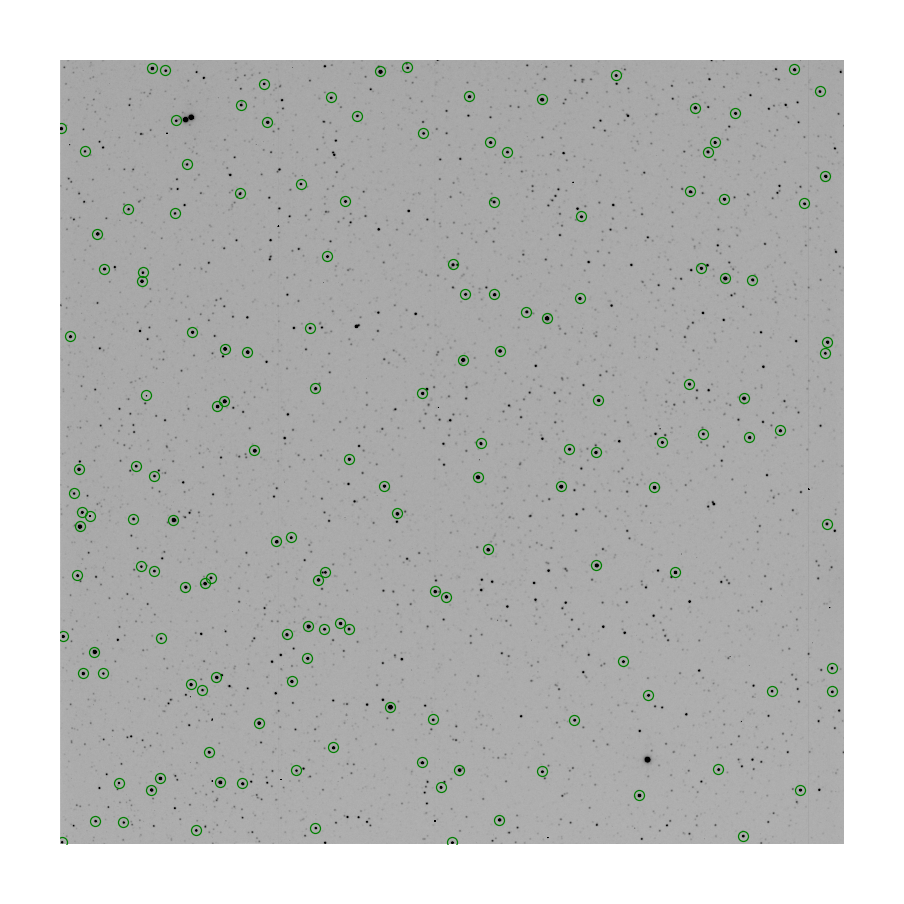

In [40]:
# reference image name

rootName = "n20190621.GuideCal.i.0056"

refFile = f"{rootName}.fits"

# full path version

fitsFile = str(Path(dataDir) / f"{refFile}")

# get the telescope RA/Dec of the reference image 

refCoords = sg.getCoords(fitsFile)

refDec = refCoords.dec.value
refCosDec = np.cos(np.radians(refCoords.dec.value))

#print(f"reference image declination: {refDec} deg")

# image examination...

t0 = time.time()
numObj, medFW, medEll, sky, skySig = sg.imExamine(fitsFile)
print(f"Image Stats: numStars: {numObj}. med FWHM: {medFW:.2f} pix, med Ell: {medEll:.3f}, sky: {sky:.2f}+/-{skySig:.2f} adu")

if sg.maxFWHM < 2*medFW:
    print(f"increasing max FWHM from {sg.maxFWHM:.2f} to {2*medFW:.2f}")
    sg.maxFWHM = 2*medFW

refX,refY = sg.findStars(fitsFile)
dt = time.time() - t0

numRef = len(refX)
print(f"Done: Found {numRef} stars on the reference image, exectime {dt:.3f} seconds")

fig,ax = plt.subplots(figsize=(wInches/4,hInches/4),dpi=dpi)

hdu = fits.open(fitsFile,uint=False)    
img = hdu[0].data
hdr = hdu[0].header
naxis1 = hdr['naxis1']
naxis2 = hdr['naxis2']
hdu.close()

medImg = np.median(img)
stdImg = np.std(img)

zMin = medImg - stdImg
zMax = medImg + 2*stdImg

plt.imshow(img,cmap=plt.cm.binary,extent=[0,naxis1,naxis2,0],vmin=zMin,vmax=zMax)
plt.axis('off')

# note -0.5 pixels for plot because of differences in sep vs. matplotlib pixel coords (sep center, mpl origin)

plt.plot(refX-0.5,refY-0.5,'o',ms=1.2,mec='green',mew=0.15,mfc="None")

plt.tight_layout()
plt.plot()


### Measure stars on a target image

Use the same parameters and measure `targX,targY` for a target image drawn from one of the offset images in
the guide calibration set.

Steps:
 * Get RA/Dec coordinates with the `getCoords()` method
 * Compute the approximate pixel shift between target and reference images with the `imgOffset()` method that uses the RA/Dec coordinates in the image headers.  The shift is what his needed to move the reference star "catalog" to within a few pixels of the target star catalog to make kd-tree matching faster and more robust, especially in crowded fields.
 * Find stars in the target image with the `findStars()` method.

Plot target stars on the image as red circles, the reference stars from the previous image as cyan crosses at
their original positions, and the estimated shifted reference star set as cyan circles.  The cyan circles should
surround most of the red circles with target image guide stars, showing the potential matches.

This does not do the matching.


dx0=1.0351 pix dy0=-128.9027 pix  (pixScale=0.896 arcsec/pix)
Good guide stars = 1.2<FWHM<4.0, ell<0.300, 1000.0 < peak < 52647.3 ADU
Found 144 good guide stars on Data/n20190621/n20190621.GuideCal.i.0057.fits
Done: Found 144 stars on the target image, exectime 0.164 seconds

Key:
  o (red) = target stars found
  + (cyan) = reference stars
  o (cyan) = target stars matched with reference stars


[]

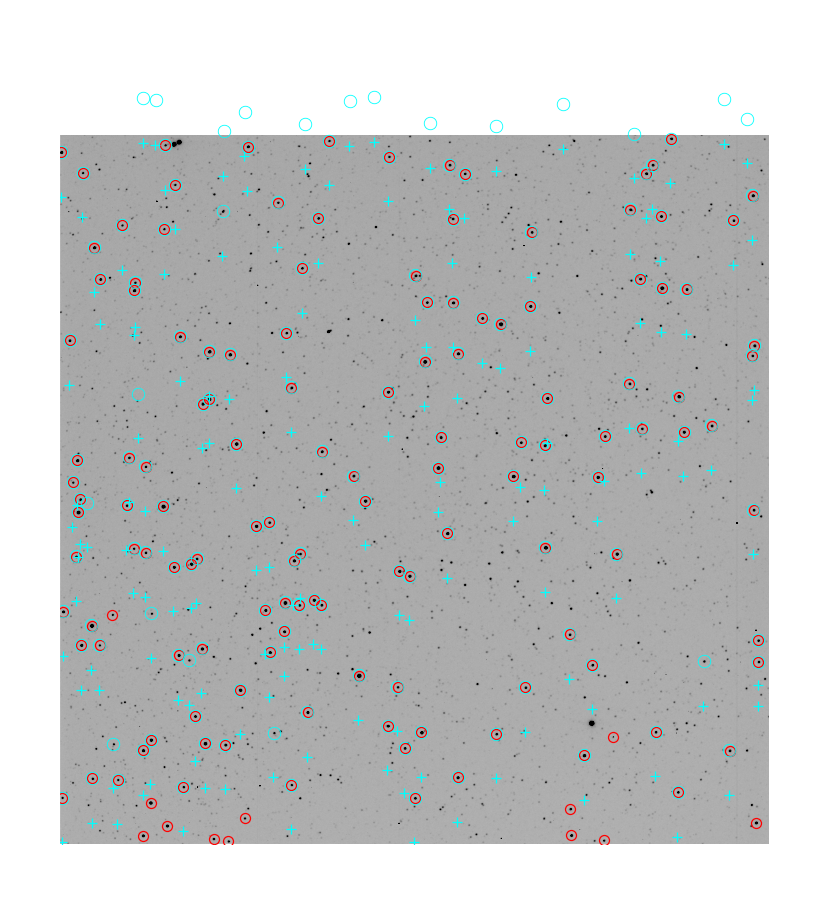

In [41]:
# reference image name

rootName = "n20190621.GuideCal.i.0057"
#rootName = "n20190620.KS14C005909.i.0372"

targFile = f"{rootName}.fits"

# full path version

fitsFile = str(Path(dataDir) / f"{targFile}")
  
# get the image RA/Dec and compute the estimated relative offset in pixels from the
# telescope coordinates

targCoords = sg.getCoords(fitsFile)

dx0, dy0 = sg.imgOffset(refCoords,targCoords)
print(f"dx0={dx0:.4f} pix dy0={dy0:.4f} pix  (pixScale={sg.pixScale:.3f} arcsec/pix)")

# find stars in the target image

t0 = time.time()
targX,targY = sg.findStars(fitsFile)
dt = time.time() - t0
numTarg = len(targX)
print(f"Done: Found {numTarg} stars on the target image, exectime {dt:.3f} seconds")

# show the image and the stars found

fig,ax = plt.subplots(figsize=(wInches/4,hInches/4),dpi=dpi)

hdu = fits.open(fitsFile,uint=False)    
img = hdu[0].data
hdr = hdu[0].header
naxis1 = hdr['naxis1']
naxis2 = hdr['naxis2']
hdu.close()

medImg = np.median(img)
stdImg = np.std(img)

zMin = medImg - stdImg
zMax = medImg + 2*stdImg

plt.imshow(img,cmap=plt.cm.binary,extent=[0,naxis1,naxis2,0],vmin=zMin,vmax=zMax)
plt.axis('off')

# note -0.5 pixels for plot because of differences in sep vs. matplotlib pixel coords (sep center, mpl origin)

plt.plot(targX-0.5,targY-0.5,'o',ms=1.2,mec='red',mew=0.15,mfc="None",zorder=9)
print("\nKey:\n  o (red) = target stars found")

# plot reference stars as crosses

plt.plot(refX-0.5,refY-0.5,"+",ms=1.2,mec='cyan',mew=0.15,mfc="None",zorder=10)
print("  + (cyan) = reference stars")

plt.plot(refX-0.5+dx0,refY-0.5+dy0,"o",ms=1.5,mec='cyan',mew=0.1,mfc="None",zorder=10)
print("  o (cyan) = target stars matched with reference stars")

plt.tight_layout()
plt.plot()


## Compute the relative shift

The last steps uses the `findShift()` method that matches the reference image star catalog (refX,refY) and the
target image star cataog (targX,targY), using the estimated inter-image shift computed with `findShift()` in the
previous cell.

Display the results in text, comparing the computed median and mean shifts from the kd-tree matched catalogs
and the estimated shifts that went into `findShift()` as a first guess.

In [42]:
t0 = time.time()
dX,dY,dXoff,dYoff,nm = sg.findShift(refX,refY,targX,targY,dx0=dx0,dy0=dy0)
dt = time.time() - t0

print(f"\n{nm} matches found")
# geometric shift

dXavg = np.mean(dXoff)
dXsig = np.std(dXoff)
dYavg = np.mean(dYoff)
dYsig = np.std(dYoff)

print(f" median dX,dY = {dX:.3f}, {dY:.3f} pix")
print(f"   mean dX,dY = {dXavg:.3f}, {dYavg:.3f} pix; sig: {dXsig:.3f},{dYsig:.3f}; exec time {dt:.4f} sec")
print(f"est'd dX0,dY0 = {dx0:.3f}, {dy0:.3f} pix")

Found 132 guide star matches, computing offset...
Offset dX=1.559 pix, dY=-128.234 pix

132 matches found
 median dX,dY = 1.559, -128.234 pix
   mean dX,dY = 1.541, -128.252 pix; sig: 0.161,0.226; exec time 0.0012 sec
est'd dX0,dY0 = 1.035, -128.903 pix


## Guider Calibration

We now work through the guide calibration process, developing a variant on the 2016 version, but with 
some changes (and bug fixes).

This version uses the `Guider` class instance routines for star finding, shift finding, and other image-level
functions.  This helps prototype the steps for the ultimate `calibrate()` method for the `Guider` class.

Image Stats: numStars: 396. med FWHM: 1.62 pix, med Ell: 0.100, sky: 2352.73+/-10.59 adu
Found 31 good guide stars on Data/n20190621/n20190621.GuideCal.i.0056.fits

Data/n20190621/n20190621.GuideCal.i.0057.fits:
Found 31 good guide stars on Data/n20190621/n20190621.GuideCal.i.0056.fits
Found 32 good guide stars on Data/n20190621/n20190621.GuideCal.i.0057.fits
dx0=1.0351 pix dy0=-128.9027 pix  (pixScale=0.896 arcsec/pix)
found 28 matches: dX=1.565 dY=-128.263

Data/n20190621/n20190621.GuideCal.i.0058.fits:
Offset dX=1.565 pix, dY=-128.263 pix
Found 31 good guide stars on Data/n20190621/n20190621.GuideCal.i.0058.fits
dx0=-0.4119 pix dy0=129.4384 pix  (pixScale=0.896 arcsec/pix)
found 18 matches: dX=-1.093 dY=128.323

Data/n20190621/n20190621.GuideCal.i.0059.fits:
Offset dX=-1.093 pix, dY=128.323 pix
Found 29 good guide stars on Data/n20190621/n20190621.GuideCal.i.0059.fits
dx0=-152.9180 pix dy0=0.4988 pix  (pixScale=0.896 arcsec/pix)
found 20 matches: dX=-151.761 dY=-1.359

Data/n2019062

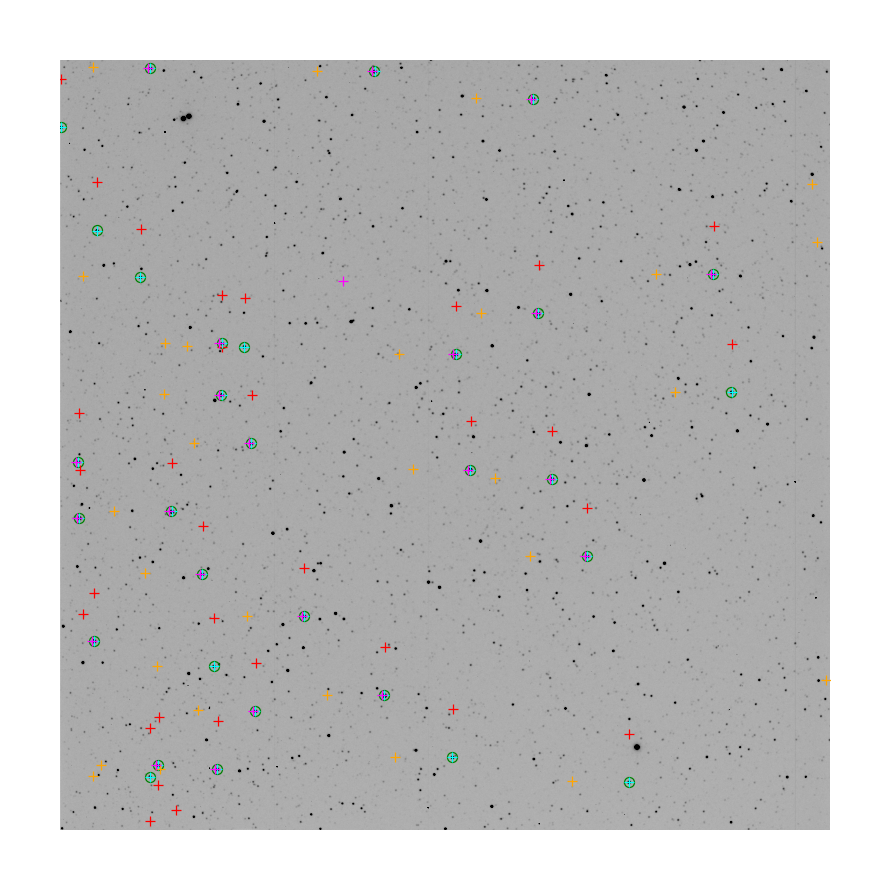

In [50]:
# guider calibration 

mx = sg.calXStep  # guider move in x - units of seconds
my = sg.calYStep  # guider move in y - units of seconds

offsetSeq = [(mx,0),(-mx,0),(0,my),(0,-my)]

# guide calibration images

rootName = "n20190621.GuideCal.i"
refImage = 56
calImages = np.arange(refImage+1,refImage+5)

# set the science guider star finding parameters

sg.threshold = 30
sg.minPeak = 4000
sg.maxEll = 0.3
sg.maxFWHM = 4.0
sg.ccdRot = 90.0
sg.verbose = False

# timer

t0 = time.time()

# Reference image

refImg = str(Path(dataDir) / f"{rootName}.{refImage:04d}.fits")

# quick image analysis

numObj, medFW, medEll, sky, skySig = sg.imExamine(fitsFile)
print(f"Image Stats: numStars: {numObj}. med FWHM: {medFW:.2f} pix, med Ell: {medEll:.3f}, sky: {sky:.2f}+/-{skySig:.2f} adu")

# run guiderInit() in testing mode

sg.calibrated = True # this is needed as we're doing the below outside of the class

try:
    sg.guiderInit(refImg)
except Exception as exp:
    print(f"Could not init guider: {exp}")

print(sg.msg)
refX = sg.refX
refY = sg.refY

# display the reference image and mark the guide stars found

fig,ax = plt.subplots(figsize=(wInches/4,hInches/4),dpi=dpi)

hdu = fits.open(refImg,uint=False)    
img = hdu[0].data
hdr = hdu[0].header
naxis1 = hdr['naxis1']
naxis2 = hdr['naxis2']
hdu.close()

medImg = np.median(img)
stdImg = np.std(img)

zMin = medImg - stdImg
zMax = medImg + 2*stdImg

plt.imshow(img,cmap=plt.cm.binary,extent=[0,naxis1,naxis2,0],vmin=zMin,vmax=zMax)
plt.axis('off')

# note -0.5 pixels for plot because of differences in sep vs. matplotlib pixel coords (sep center, mpl origin)

plt.plot(refX-0.5,refY-0.5,'o',ms=1.2,mec='green',mew=0.15,mfc="None")

# here we are measuring the calibration images.  Eventually these will be acquired and analyzed
# within the calibrate() method.

# measure the calibration images

dX = []
dY = []
colors = ['red','cyan','orange','magenta']
for i in range(len(calImages)):
    calFile = str(Path(dataDir) / f"{rootName}.{calImages[i]:04d}.fits")

    print(f"\n{calFile}:")

    calCoords = sg.getCoords(calFile)
    print(sg.msg)
    
    # find stars
    
    calX,calY = sg.findStars(calFile)
    print(sg.msg)
    
    # plt.plot(calX-0.5,calY-0.5,'+',ms=1.2,mec='cyan',mew=0.15,mfc="None")
    plt.plot(calX-0.5,calY-0.5,'+',ms=1.2,mec=colors[i],mew=0.15,mfc="None")

    if i == 0:
        dx0, dy0 = sg.imgOffset(refCoords,calCoords)
        delX,delY,dXoff,dYoff,nm = sg.findShift(refX,refY,calX,calY,dx0=dx0,dy0=dy0)
    else:
        delX,delY,dXoff,dYoff,nm = sg.findShift(lastX,lastY,calX,calY)
        dx0, dy0 = sg.imgOffset(lastCoords,calCoords)
        
    print(f"dx0={dx0:.4f} pix dy0={dy0:.4f} pix  (pixScale={sg.pixScale:.3f} arcsec/pix)")

    lastCoords = calCoords
    lastX = calX
    lastY = calY

    dX.append(delX)
    dY.append(delY)
    print(f"found {nm} matches: dX={delX:.3f} dY={delY:.3f}")
    
# summary

print("\nSummary shifts:")
for i in range(len(dX)):
    print(f"  dx{i+1},dy{i+1}: {dX[i]:8.3f}, {dY[i]:8.3f}")
    
print("\nBacklash:")
print(f" guider x: {dX[0]+dX[1]:5.3f}, {dX[2]+dX[3]:5.3f} pix")
print(f" guider y: {dY[0]+dY[1]:5.3f}, {dY[2]+dY[3]:5.3f} pix")

# compute guider calibration parameters

alpha1 = 0.5*(dX[0]-dX[1])
delta1 = 0.5*(dY[0]-dY[1])
dist1 = np.sqrt(alpha1*alpha1 + delta1*delta1)
theta1 = np.arctan2(delta1,alpha1)
print(f"\nalpha1={alpha1:8.3f} delta1={delta1:8.3f} dist1={dist1:8.3f} theta1={np.degrees(theta1):.4f}")

alpha2 = 0.5*(dX[2]-dX[3])
delta2 = 0.5*(dY[2]-dY[3])
dist2 = np.sqrt(alpha2*alpha2 + delta2*delta2)
theta2 = 0.5*np.pi + np.arctan2(delta2,alpha2)
print(f"alpha2={alpha2:8.3f} delta2={delta2:8.3f} dist2={dist2:8.3f} theta2={np.degrees(theta2):.4f}")

mytheta = 0.5*(theta1+theta2)
myb = -mx/dist1 # sec/pixel
mya = my/dist2  # sec/pixel
myb0 = myb*sg.refCosDec # b coefficient at dec=0 degrees

print(f"\nGuider Coefficients: a = {mya:.4f} ; b = {myb:.4f} ; b0 = {myb0:.4f} ; angle = {np.degrees(mytheta):.4f} degrees")

# inform the Guider class we have a calibration

sg.setCalibration(mya,myb0,np.degrees(mytheta))

# this is equivalent to setting Guider class properties directly:
#  sg.calibrated = True
#  sg.guide_a = mya
#  sg.guide_b0 = sg.refCosDec*myb
#  sg.guide_th = np.degrees(mytheta)

# apply the calibration

print(f"\nApplication:")
for i in range(len(dX)):
    tmx, tmy = sg.guideOffset(dX[i],dY[i])
    
    #tmx = myb*dY[i]*np.sin(mytheta) + mya*dX[i]*np.cos(mytheta)
    #tmy = myb*dY[i]*np.cos(mytheta) - mya*dX[i]*np.sin(mytheta)
    
    emx = tmx + offsetSeq[i][0]
    emy = tmy + offsetSeq[i][1]
    print(f"  move {i+1}: {tmx:7.3f},{tmy:7.3f}; actual: {-offsetSeq[i][0]:5.1f},{-offsetSeq[i][1]:5.1f}; diff: {emx:6.3f},{emy:6.3f}")

dt = time.time() - t0
print(f"\nexecution time: {dt:.3f} sec")